<a href="https://colab.research.google.com/github/nikolay909694/StatPrac/blob/main/DZ3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem 1
Implement serial test and apply to a `samples`

In [1]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = [rng() for _ in range(1000)]

def serial_test(data, grid=10):
    data = data[:len(data) - len(data) % 2]

    x_vals = []
    y_vals = []
    for i in range(0, len(data), 2):
        x_vals.append(data[i])
        y_vals.append(data[i + 1])

    counts, _, _ = np.histogram2d(x_vals, y_vals, bins=grid)

    observed = counts.ravel()
    n_pairs = len(x_vals)
    n_cells = grid * grid
    expected = np.ones(n_cells) * (n_pairs / n_cells)

    chi2, p = stats.chisquare(observed, expected)
    return chi2, p

chi2, p = serial_test(samples)
print(f"chi-square statistic = {chi2:.4f}")
print(f"p-value = {p:.4f}")


chi-square statistic = 100.4000
p-value = 0.4418


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [2]:
import numpy as np
import scipy.stats as stats

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

def rng_good(m=2**32, a=1103515245, c=12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m

def test_3d(seq, k=12):
    seq = seq[:len(seq)-len(seq)%3]
    n = len(seq)//3
    grid = np.zeros((k,k,k))
    for i in range(n):
        x,y,z = seq[3*i], seq[3*i+1], seq[3*i+2]
        grid[int(x*k)%k, int(y*k)%k, int(z*k)%k] += 1
    obs = grid.flatten()
    exp = np.full(k**3, n/k**3)
    return stats.chisquare(obs, exp)

rng_bad.current = rng_good.current = 1
bad = [rng_bad() for _ in range(60000)]
good = [rng_good() for _ in range(60000)]

for name, data in [('ПЛОХОЙ (RANDU)', bad), ('ХОРОШИЙ (LCG)', good)]:
    res = test_3d(data, k=12)
    status = "bad" if res.pvalue < 0.05 else "good"
    print(f"\n{name}:")
    print(f"  χ² = {res.statistic:.2f}")
    print(f"  p-value = {res.pvalue:}")
    print(f"  Статус: {status}")



ПЛОХОЙ (RANDU):
  χ² = 3167.81
  p-value = 7.003651690318202e-88
  Статус: bad

ХОРОШИЙ (LCG):
  χ² = 1701.26
  p-value = 0.6659642788673542
  Статус: good


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

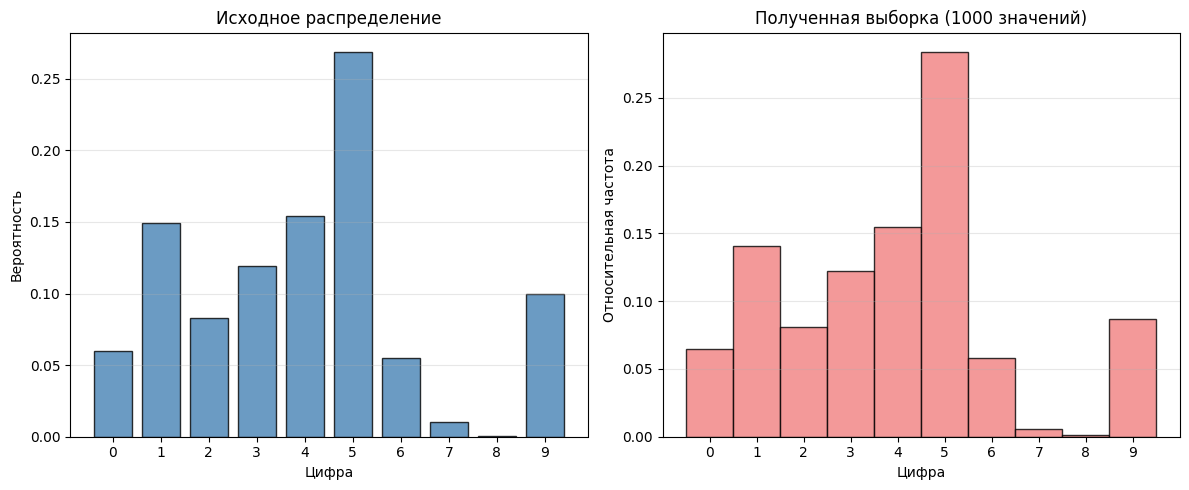

Полученные частоты:
  Цифра 0: 65 раз (0.065)
  Цифра 1: 141 раз (0.141)
  Цифра 2: 81 раз (0.081)
  Цифра 3: 122 раз (0.122)
  Цифра 4: 155 раз (0.155)
  Цифра 5: 284 раз (0.284)
  Цифра 6: 58 раз (0.058)
  Цифра 7: 6 раз (0.006)
  Цифра 8: 1 раз (0.001)
  Цифра 9: 87 раз (0.087)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

digits = list(range(10))
weights = [0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2]

probs = np.array(weights) / np.sum(weights)

prob_digit_pairs = [(p, d) for p, d in zip(probs, digits)]
prob_digit_pairs.sort(reverse=True)

sorted_probs = [pair[0] for pair in prob_digit_pairs]
sorted_digits = [pair[1] for pair in prob_digit_pairs]
cumulative = np.cumsum(sorted_probs)

np.random.seed(42)
sample_size = 1000
random_values = np.random.rand(sample_size)

samples = []
for r in random_values:
    for i, cum in enumerate(cumulative):
        if r < cum:
            samples.append(sorted_digits[i])
            break

samples = np.array(samples)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(digits, probs, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Исходное распределение')
plt.xlabel('Цифра')
plt.ylabel('Вероятность')
plt.xticks(digits)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(samples, bins=np.arange(-0.5, 10, 1), density=True,
         color='lightcoral', edgecolor='black', alpha=0.8)
plt.title('Полученная выборка (1000 значений)')
plt.xlabel('Цифра')
plt.ylabel('Относительная частота')
plt.xticks(digits)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Полученные частоты:")
values, counts = np.unique(samples, return_counts=True)
for v, c in zip(values, counts):
    print(f"  Цифра {int(v)}: {c} раз ({c/sample_size:.3f})")

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

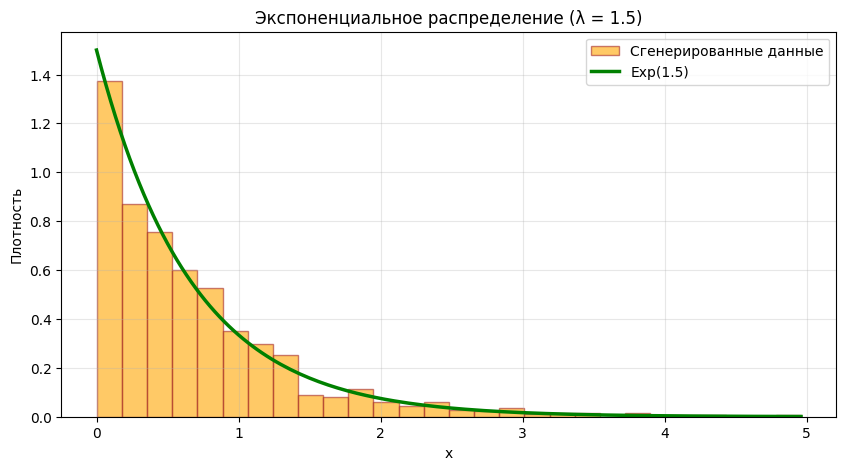

In [4]:
import numpy as np
import matplotlib.pyplot as plt

lambda_value = 1.5
sample_size = 1000

uniform_numbers = np.random.uniform(0, 1, sample_size)
transformed = -np.log(1 - uniform_numbers) / lambda_value

plt.figure(figsize=(10, 5))
plt.hist(transformed, bins=28, density=True, color='orange', edgecolor='brown', alpha=0.6, label='Сгенерированные данные')
x_values = np.linspace(0, np.max(transformed), 150)
theoretical = lambda_value * np.exp(-lambda_value * x_values)
plt.plot(x_values, theoretical, 'g-', linewidth=2.5, label=f'Exp({lambda_value})')
plt.title(f'Экспоненциальное распределение (λ = {lambda_value})')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

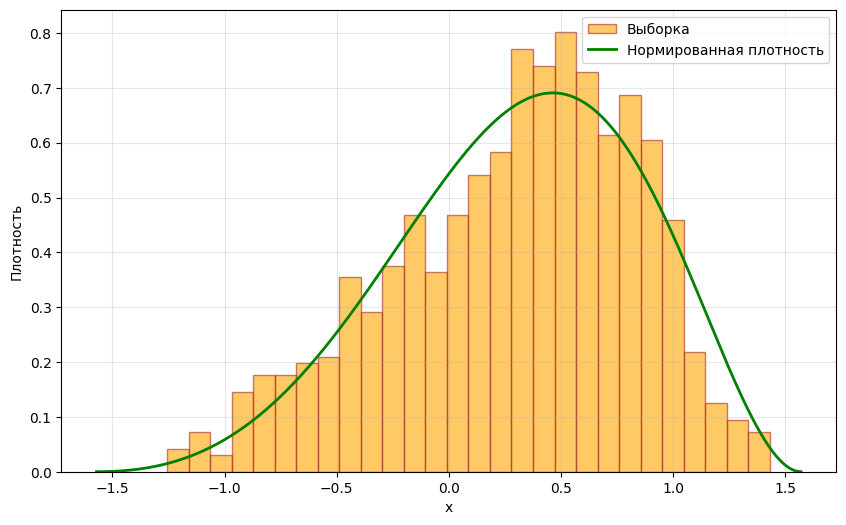

In [5]:
import numpy as np
import matplotlib.pyplot as plt

a, b = -np.pi/2, np.pi/2
target = lambda x: np.exp(x) * np.cos(x)**2

x_vals = np.linspace(a, b, 500)
max_val = max(target(x_vals))

np.random.seed(42)
samples = []
trials = 0

while len(samples) < 1000:
    trials += 1
    x = np.random.uniform(a, b)
    y = np.random.uniform(0, max_val)
    if y <= target(x):
        samples.append(x)

samples = np.array(samples)
accept_rate = 1000 / trials * 100

dx = x_vals[1] - x_vals[0]
norm_const = np.sum(target(x_vals) * dx)
target_norm = lambda x: target(x) / norm_const

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=28, density=True, alpha=0.6, color='orange', edgecolor='brown', label='Выборка')
plt.plot(x_vals, target_norm(x_vals), 'g-', linewidth=2, label='Нормированная плотность')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

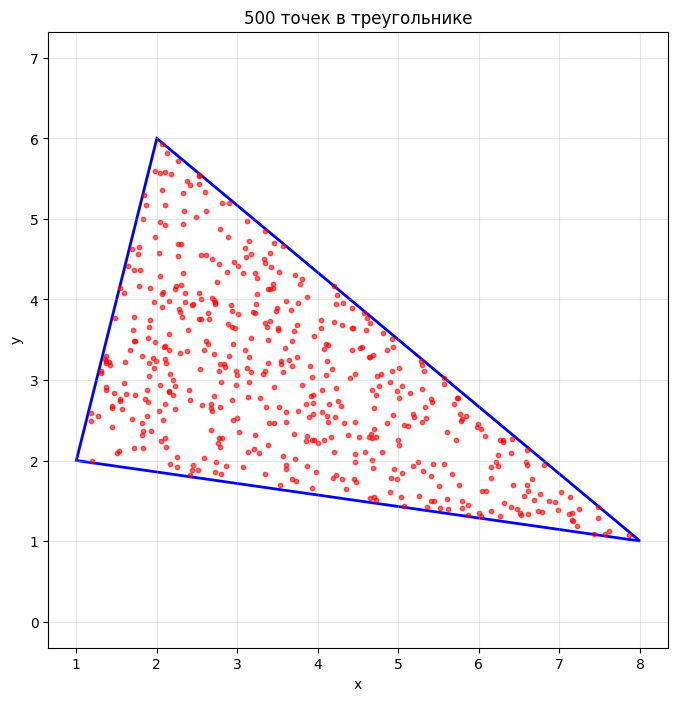

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

def sample_triangle(n_points, seed=42):
    np.random.seed(seed)
    u = np.random.random(n_points)
    v = np.random.random(n_points)

    reflection = (u + v) > 1
    u[reflection] = 1 - u[reflection]
    v[reflection] = 1 - v[reflection]

    points = (u[:, np.newaxis] * A +
              v[:, np.newaxis] * B +
              (1 - u - v)[:, np.newaxis] * C)
    return points

samples = sample_triangle(500, seed=123)

fig, ax = plt.subplots(figsize=(8, 8))
triangle = Polygon([A, B, C], closed=True, fill=False, edgecolor='blue', linewidth=2)
ax.add_patch(triangle)
ax.scatter(samples[:, 0], samples[:, 1], s=10, color='red', alpha=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('500 точек в треугольнике')
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

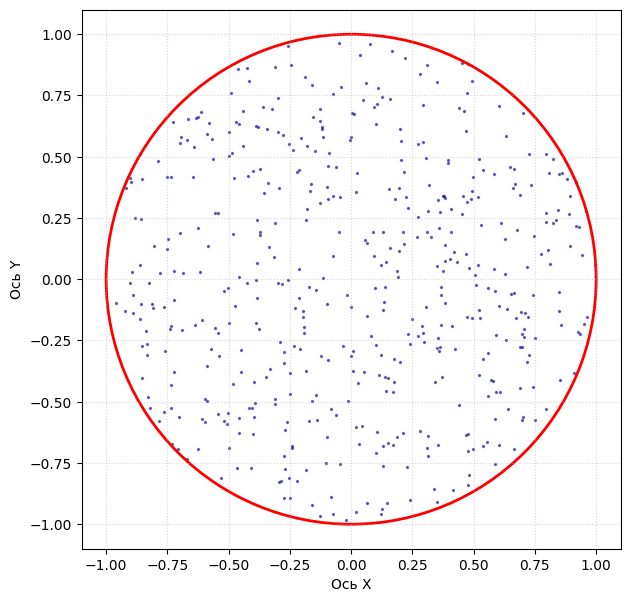

In [7]:
import numpy as np
import matplotlib.pyplot as plt

n = 500
np.random.seed(42)

random_angles = np.random.random(n) * 2 * np.pi
random_radii = np.random.random(n)

radii = np.sqrt(random_radii)

x_coords = radii * np.cos(random_angles)
y_coords = radii * np.sin(random_angles)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x_coords, y_coords, c='darkblue', s=8, alpha=0.5, marker='.')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel('Ось X')
ax.set_ylabel('Ось Y')

circle = plt.Circle((0, 0), 1, fill=False, color='red', linewidth=2)
ax.add_patch(circle)
plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.


Среднее значение:
  Теоретическое: [4, 7]
  Выборочное:    [4.255, 7.157]
  Ошибка:        [0.255, 0.157]

Ковариационная матрица:
  Теоретическая:
[[20 -4]
 [-4 40]]
  Выборочная:
[[20.603 -4.05 ]
 [-4.05  37.043]]
  Ошибка:
[[0.603 0.05 ]
 [0.05  2.957]]


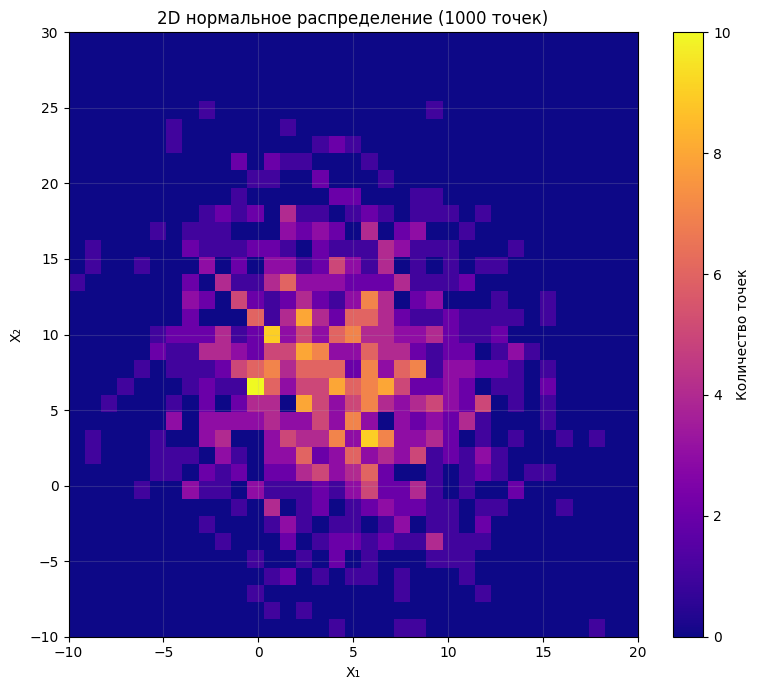

In [10]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([4, 7])
sigma = np.array([[20, -4], [-4, 40]])

def box_muller_polar(n, seed=42):
    np.random.seed(seed)
    samples = np.zeros((n, 2))
    count = 0

    while count < n:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u**2 + v**2

        if 0 < s < 1:
            factor = np.sqrt(-2 * np.log(s) / s)
            samples[count, 0] = u * factor
            samples[count, 1] = v * factor
            count += 1

    return samples

z = box_muller_polar(1000)

L = np.linalg.cholesky(sigma)
x = mu + z @ L.T

sample_mean = np.mean(x, axis=0)
sample_cov = np.cov(x, rowvar=False)

print(f"\nСреднее значение:")
print(f"  Теоретическое: [{mu[0]}, {mu[1]}]")
print(f"  Выборочное:    [{sample_mean[0]:.3f}, {sample_mean[1]:.3f}]")
print(f"  Ошибка:        [{abs(sample_mean[0] - mu[0]):.3f}, {abs(sample_mean[1] - mu[1]):.3f}]")

print(f"\nКовариационная матрица:")
print("  Теоретическая:")
print(sigma)
print("  Выборочная:")
print(np.round(sample_cov, 3))
print("  Ошибка:")
print(np.round(np.abs(sample_cov - sigma), 3))

plt.figure(figsize=(8, 7))
hist = plt.hist2d(x[:, 0], x[:, 1], bins=35, cmap='plasma',
                   range=[[-10, 20], [-10, 30]])
plt.colorbar(label='Количество точек')
plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('2D нормальное распределение (1000 точек)')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()